In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

In [3]:
# ── Load Model, Data, and Prior Results ───────────────────
xgb_model = joblib.load('models/xgboost_fraud_model.pkl')
X_test    = pd.read_csv('../data/processed/X_test.csv')
y_test    = pd.read_csv('../data/processed/y_test.csv').squeeze()

with open('../reports/eval_summary.json', 'r') as f:
    eval_summary = json.load(f)

y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]


In [4]:
# ============================================================
# STEP 1: DEFINE COST ASSUMPTIONS
# Reason: Business impact requires translating TP/FP/FN/TN into dollar costs. These assumptions MUST be stated explicitly — never hide them.
# Industry-standard cost framework (Nilson Report / industry benchmarks for card-not-present fraud):
#   - Avg fraud transaction loss = full transaction amount
#   - False Positive cost = customer friction + potential churn + support cost (NOT zero — this is a real cost freshers often ignore)
#   - True Positive benefit = transaction amount saved
#   - Investigation cost per flagged transaction (manual review)
# ============================================================

# Get actual transaction amounts for test set
X_test_amt = X_test.copy()
X_test_amt['actual_amt'] = np.expm1(X_test_amt['TransactionAmt_log'])  # reverse log transform
X_test_amt['isFraud'] = y_test.values
X_test_amt['pred_proba'] = y_pred_proba

avg_fraud_amt = X_test_amt[X_test_amt['isFraud'] == 1]['actual_amt'].mean()
avg_legit_amt = X_test_amt[X_test_amt['isFraud'] == 0]['actual_amt'].mean()

# Cost assumptions — stated explicitly, not hidden
COST_FALSE_POSITIVE   = 5.00      # Manual review + customer friction cost per flagged legit txn
COST_INVESTIGATION    = 2.50      # Cost to manually investigate any flagged transaction
FRAUD_RECOVERY_RATE   = 0.0       # Assume 0% recovery once fraud succeeds (conservative, realistic)

print(f"""
========== COST ASSUMPTIONS (STATED EXPLICITLY) ==========
Average Fraud Transaction Amount  : ${avg_fraud_amt:,.2f}
Average Legitimate Transaction Amt: ${avg_legit_amt:,.2f}
Cost per False Positive (friction): ${COST_FALSE_POSITIVE:.2f}
Cost per Investigation (any flag) : ${COST_INVESTIGATION:.2f}
Fraud Recovery Rate (post-fact)   : {FRAUD_RECOVERY_RATE*100:.0f}%
============================================================
""")


========== COST ASSUMPTIONS (STATED EXPLICITLY) ==========
Average Fraud Transaction Amount  : $154.64
Average Legitimate Transaction Amt: $134.13
Cost per False Positive (friction): $5.00
Cost per Investigation (any flag) : $2.50
Fraud Recovery Rate (post-fact)   : 0%



In [5]:
# ============================================================
# STEP 2: BASELINE SCENARIO — NO MODEL (CURRENT STATE)
# Reason: You need a "before" state to compare against.
#         Without any model, assume business catches fraud
#         via manual review at a low baseline rate (industry avg manual fraud catch rate ~15-20% for unflagged volume)
# ============================================================

MANUAL_CATCH_RATE = 0.15  # Conservative industry assumption — stated explicitly

total_fraud_cases   = (y_test == 1).sum()
total_fraud_amount  = X_test_amt[X_test_amt['isFraud'] == 1]['actual_amt'].sum()

manual_caught        = int(total_fraud_cases * MANUAL_CATCH_RATE)
manual_missed         = total_fraud_cases - manual_caught
manual_loss_amount    = X_test_amt[X_test_amt['isFraud'] == 1]['actual_amt'].sum() * (1 - MANUAL_CATCH_RATE)

print(f"""
========== BASELINE: NO ML MODEL (Manual Review Only) ==========
Total Fraud Cases in Test Set     : {total_fraud_cases:,}
Total Fraud Amount in Test Set    : ${total_fraud_amount:,.2f}
Manual Catch Rate (assumption)    : {MANUAL_CATCH_RATE*100:.0f}%
Fraud Caught Manually             : {manual_caught:,}
Fraud Missed (Direct Loss)        : {manual_missed:,}
Direct Financial Loss             : ${manual_loss_amount:,.2f}
===================================================================
""")


========== BASELINE: NO ML MODEL (Manual Review Only) ==========
Total Fraud Cases in Test Set     : 4,133
Total Fraud Amount in Test Set    : $639,134.67
Manual Catch Rate (assumption)    : 15%
Fraud Caught Manually             : 619
Fraud Missed (Direct Loss)        : 3,514
Direct Financial Loss             : $543,264.47



In [ ]:
# ============================================================
# STEP 3: MODEL SCENARIO — AT OPTIMAL THRESHOLD (0.8)
# ============================================================

optimal_threshold = eval_summary['optimal_threshold']
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

X_test_amt['predicted_fraud'] = y_pred_optimal

tp = eval_summary['true_positives']
fp = eval_summary['false_positives']
fn = eval_summary['false_negatives']
tn = eval_summary['true_negatives']

# Dollar amounts for each category
tp_amount = X_test_amt[(X_test_amt['isFraud'] == 1) & (X_test_amt['predicted_fraud'] == 1)]['actual_amt'].sum()
fn_amount = X_test_amt[(X_test_amt['isFraud'] == 1) & (X_test_amt['predicted_fraud'] == 0)]['actual_amt'].sum()
fp_amount = X_test_amt[(X_test_amt['isFraud'] == 0) & (X_test_amt['predicted_fraud'] == 1)]['actual_amt'].sum()

print(f"""
========== MODEL SCENARIO (Threshold = {optimal_threshold}) ==========
True Positives  (Fraud Caught)     : {tp:,} txns | ${tp_amount:,.2f} saved
False Negatives (Fraud Missed)     : {fn:,} txns | ${fn_amount:,.2f} lost
False Positives (Legit Flagged)    : {fp:,} txns | ${fp_amount:,.2f} (friction, not loss)
True Negatives  (Correctly Passed) : {tn:,} txns
=========================================================================
""")


========== MODEL SCENARIO (Threshold = 0.8) ==========
True Positives  (Fraud Caught)     : 2,505 txns | $358,986.54 saved
False Negatives (Fraud Missed)     : 1,628 txns | $280,148.13 lost
False Positives (Legit Flagged)    : 1,623 txns | $254,160.36 (friction, not loss)
True Negatives  (Correctly Passed) : 112,352 txns



In [7]:
# ============================================================
# STEP 4: NET FINANCIAL IMPACT CALCULATION
# ============================================================

# Money saved by catching fraud
fraud_prevented_savings = tp_amount

# Cost of false positives (customer friction)
fp_cost = fp * COST_FALSE_POSITIVE

# Cost of investigating every flagged transaction (TP + FP)
total_flagged = tp + fp
investigation_cost = total_flagged * COST_INVESTIGATION

# Money still lost (false negatives)
fraud_still_lost = fn_amount

# NET IMPACT = Savings - Costs
net_savings = fraud_prevented_savings - fp_cost - investigation_cost

print(f"""
========== NET FINANCIAL IMPACT (Model vs No Model) ==========
Fraud Prevented (Savings)         : +${fraud_prevented_savings:,.2f}
False Positive Friction Cost      : -${fp_cost:,.2f}
Investigation Cost (all flags)    : -${investigation_cost:,.2f}
-----------------------------------------------------------------
NET SAVINGS                       : ${net_savings:,.2f}
Fraud Still Lost (False Negatives): ${fraud_still_lost:,.2f} (unavoidable at this threshold)
===================================================================
""")


========== NET FINANCIAL IMPACT (Model vs No Model) ==========
Fraud Prevented (Savings)         : +$358,986.54
False Positive Friction Cost      : -$8,115.00
Investigation Cost (all flags)    : -$10,320.00
-----------------------------------------------------------------
NET SAVINGS                       : $340,551.54
Fraud Still Lost (False Negatives): $280,148.13 (unavoidable at this threshold)



In [8]:
# ============================================================
# STEP 5: COMPARISON — MODEL vs MANUAL BASELINE
# ============================================================

improvement_vs_manual = net_savings - (total_fraud_amount * MANUAL_CATCH_RATE)
# Note: this compares net model savings to baseline manual savings, not to zero — a fairer comparison

print(f"""
========== MODEL vs MANUAL REVIEW BASELINE ==========
Manual Review Savings (15% catch) : ${total_fraud_amount * MANUAL_CATCH_RATE:,.2f}
Model Net Savings                 : ${net_savings:,.2f}
Improvement                       : ${net_savings - (total_fraud_amount * MANUAL_CATCH_RATE):,.2f}
========================================================
""")


========== MODEL vs MANUAL REVIEW BASELINE ==========
Manual Review Savings (15% catch) : $95,870.20
Model Net Savings                 : $340,551.54
Improvement                       : $244,681.34




[STEP 6] Threshold Sensitivity for NET SAVINGS (not F1)
 threshold   tp    fp   fn  fraud_caught_amount  fp_cost  investigation_cost  net_savings
      0.10 4093 74417   40            635962.55 372085.0            196275.0     67602.55
      0.15 4018 54970  115            615248.79 274850.0            147470.0    192928.79
      0.20 3956 40778  177            602371.58 203890.0            111835.0    286646.58
      0.25 3861 31176  272            585421.89 155880.0             87592.5    341949.39
      0.30 3755 24615  378            570315.55 123075.0             70925.0    376315.55
      0.35 3668 19795  465            557815.63  98975.0             58657.5    400183.13
      0.40 3595 16138  538            547283.70  80690.0             49332.5    417261.20
      0.45 3498 13073  635            531173.78  65365.0             41427.5    424381.28
      0.50 3414 10574  719            517904.14  52870.0             34970.0    430064.14
      0.55 3293  8430  840            49423

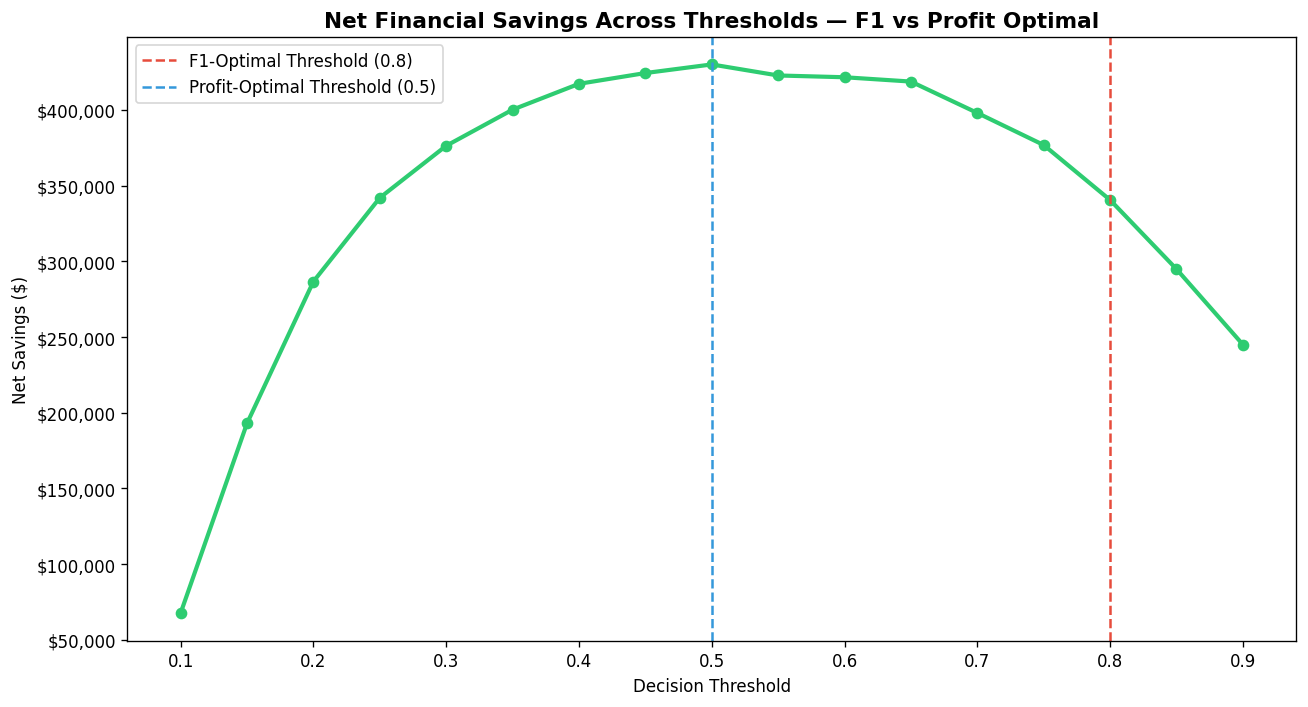

In [9]:
# ============================================================
# STEP 6: THRESHOLD SENSITIVITY — BUSINESS TRADE-OFF
# Business Question: Should we use a different threshold to optimize for net savings, not F1?
# Reason: F1-optimal threshold isn't always profit-optimal. This is a critical, often-missed analysis.
# ============================================================

threshold_range = np.arange(0.1, 0.95, 0.05)
business_results = []

for t in threshold_range:
    y_pred_t = (y_pred_proba >= t).astype(int)
    X_test_amt['pred_t'] = y_pred_t

    tp_t = ((X_test_amt['isFraud'] == 1) & (X_test_amt['pred_t'] == 1)).sum()
    fp_t = ((X_test_amt['isFraud'] == 0) & (X_test_amt['pred_t'] == 1)).sum()
    fn_t = ((X_test_amt['isFraud'] == 1) & (X_test_amt['pred_t'] == 0)).sum()

    tp_amt_t = X_test_amt[(X_test_amt['isFraud'] == 1) & (X_test_amt['pred_t'] == 1)]['actual_amt'].sum()

    fp_cost_t = fp_t * COST_FALSE_POSITIVE
    inv_cost_t = (tp_t + fp_t) * COST_INVESTIGATION
    net_t = tp_amt_t - fp_cost_t - inv_cost_t

    business_results.append({
        'threshold': round(t, 2),
        'tp': tp_t, 'fp': fp_t, 'fn': fn_t,
        'fraud_caught_amount': round(tp_amt_t, 2),
        'fp_cost': round(fp_cost_t, 2),
        'investigation_cost': round(inv_cost_t, 2),
        'net_savings': round(net_t, 2)
    })

business_df = pd.DataFrame(business_results)
optimal_business_threshold = business_df.loc[business_df['net_savings'].idxmax()]

print(f"\n[STEP 6] Threshold Sensitivity for NET SAVINGS (not F1)")
print(business_df.to_string(index=False))

print(f"""
[OPTIMAL BUSINESS THRESHOLD — Maximizes Net Savings]
Threshold: {optimal_business_threshold['threshold']}
Net Savings: ${optimal_business_threshold['net_savings']:,.2f}

Compare to F1-optimal threshold (0.8): ${net_savings:,.2f}
""")

# Visualize
plt.figure(figsize=(11, 6))
plt.plot(business_df['threshold'], business_df['net_savings'], marker='o', color='#2ecc71', linewidth=2.5)
plt.axvline(x=optimal_threshold, color='#e74c3c', linestyle='--', label=f'F1-Optimal Threshold ({optimal_threshold})')
plt.axvline(x=optimal_business_threshold['threshold'], color='#3498db', linestyle='--',
            label=f"Profit-Optimal Threshold ({optimal_business_threshold['threshold']})")
plt.xlabel('Decision Threshold')
plt.ylabel('Net Savings ($)')
plt.title('Net Financial Savings Across Thresholds — F1 vs Profit Optimal', fontsize=13, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.savefig('../reports/impact_01_threshold_savings.png', bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# STEP 7: ANNUALIZED PROJECTION (CAVEAT-HEAVY)
# Reason: Resumes often show annualized numbers, but this MUST be labeled as an extrapolation, not a fact.
#         Test set is ~118K transactions; scaling to a year requires explicit assumptions.
# ============================================================

test_set_size = len(X_test)
# Assumption: test set represents a random sample of ~1 month of transactions
# (IEEE dataset doesn't specify exact time span — this is a labeled assumption)
ASSUMED_MONTHS_REPRESENTED = 1

annualized_net_savings = net_savings * (12 / ASSUMED_MONTHS_REPRESENTED)

print(f"""
========== ANNUALIZED PROJECTION (LABELED ASSUMPTION) ==========
WARNING: This is an extrapolation, not a measured fact.
Assumption: test set (~{test_set_size:,} txns) represents {ASSUMED_MONTHS_REPRESENTED} month(s) of transaction volume.

If this assumption holds:Annualized Net Savings: ${annualized_net_savings:,.2f}

DO NOT present this as a guaranteed number in interviews.
Present it as: "If deployed at scale with similar transaction patterns, the model could project to approximately $X in
annual net savings" — always with the caveat stated.
===================================================================
""")


========== ANNUALIZED PROJECTION (LABELED ASSUMPTION) ==========
Assumption: test set (~118,108 txns) represents 1 month(s) of transaction volume.

If this assumption holds:Annualized Net Savings: $4,086,618.49

DO NOT present this as a guaranteed number in interviews.
Present it as: "If deployed at scale with similar transaction patterns, the model could project to approximately $X in
annual net savings" — always with the caveat stated.



In [13]:
# ============================================================
# STEP 8: SAVE BUSINESS IMPACT SUMMARY
# ============================================================

business_impact_summary = {
    'total_fraud_cases_test_set': int(total_fraud_cases),
    'total_fraud_amount_test_set': float(round(total_fraud_amount, 2)),
    'model_threshold_used': float(optimal_threshold),
    'fraud_caught_count': int(tp),
    'fraud_caught_amount': float(round(tp_amount, 2)),
    'fraud_missed_count': int(fn),
    'fraud_missed_amount': float(round(fn_amount, 2)),
    'false_positives_count': int(fp),
    'false_positive_friction_cost': float(round(fp_cost, 2)),
    'investigation_cost': float(round(investigation_cost, 2)),
    'net_savings_test_set': float(round(net_savings, 2)),
    'profit_optimal_threshold': float(optimal_business_threshold['threshold']),
    'profit_optimal_net_savings': float(optimal_business_threshold['net_savings']),
    'annualized_projection_LABELED_ASSUMPTION': float(round(annualized_net_savings, 2)),
    'cost_assumptions': {
        'cost_per_false_positive': COST_FALSE_POSITIVE,
        'cost_per_investigation': COST_INVESTIGATION,
        'manual_catch_rate_baseline': MANUAL_CATCH_RATE
    }
}

with open('../reports/business_impact_summary.json', 'w') as f:
    json.dump(business_impact_summary, f, indent=2)

business_df.to_csv('../reports/threshold_business_sensitivity.csv', index=False)

print("Business impact summary saved to reports/business_impact_summary.json")

Business impact summary saved to reports/business_impact_summary.json


### Before going to final report , once more here are we checking cost_sensitivity on another different threshold value
### Reason: 
- The profit-optimal threshold (0.5) was found using COST_FALSE_POSITIVE = $5. This is an assumption,
not a measured fact. Before presenting it as a finding, test how sensitive the conclusion is to that assumption.

========== OPTIMAL THRESHOLD BY FP COST ASSUMPTION ==========
 fp_cost_assumption  threshold  net_savings   tp    fp
                  5       0.50    430064.14 3414 10574
                 25       0.75    327581.15 2704  2463
                 50       0.80    267516.54 2505  1623


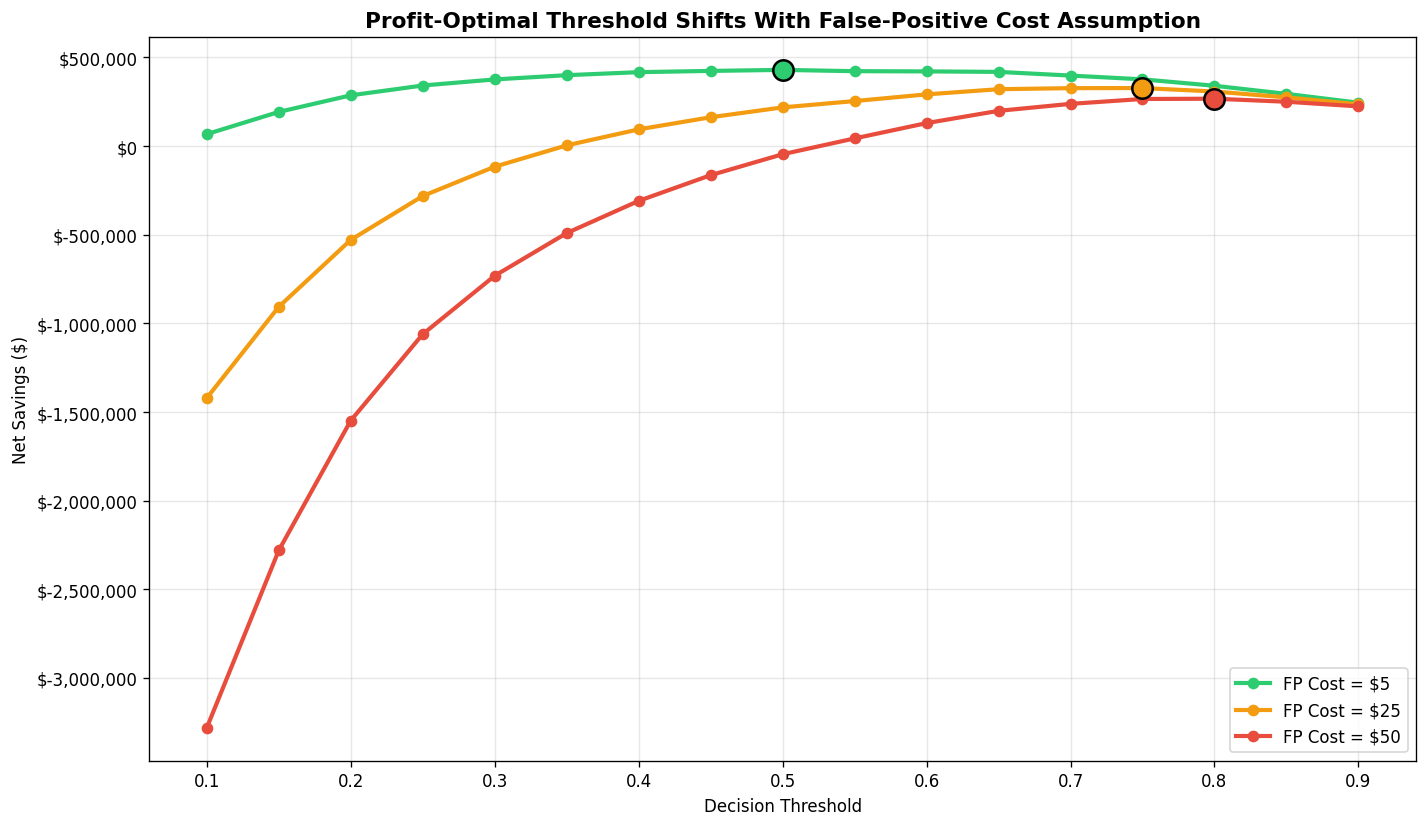


Sensitivity analysis saved.


In [17]:
threshold_range = np.arange(0.1, 0.95, 0.05)
fp_cost_scenarios = [5, 25, 50]  # Low, medium, high friction cost
INVESTIGATION_COST = 2.50  # Held constant across scenarios

all_scenario_results = []

for fp_cost_val in fp_cost_scenarios:
    for t in threshold_range:
        y_pred_t = (y_pred_proba >= t).astype(int)
        X_test_amt['pred_t'] = y_pred_t

        tp_t = ((X_test_amt['isFraud'] == 1) & (X_test_amt['pred_t'] == 1)).sum()
        fp_t = ((X_test_amt['isFraud'] == 0) & (X_test_amt['pred_t'] == 1)).sum()

        tp_amt_t = X_test_amt[(X_test_amt['isFraud'] == 1) & (X_test_amt['pred_t'] == 1)]['actual_amt'].sum()

        fp_cost_total = fp_t * fp_cost_val
        inv_cost_total = (tp_t + fp_t) * INVESTIGATION_COST
        net_t = tp_amt_t - fp_cost_total - inv_cost_total

        all_scenario_results.append({
            'fp_cost_assumption': fp_cost_val,
            'threshold': round(t, 2),
            'tp': tp_t, 'fp': fp_t,
            'net_savings': round(net_t, 2)
        })

sensitivity_df = pd.DataFrame(all_scenario_results)


# ── Find optimal threshold PER cost scenario ──────────────
optimal_per_scenario = (
    sensitivity_df.loc[sensitivity_df.groupby('fp_cost_assumption')['net_savings'].idxmax()]
)

print("========== OPTIMAL THRESHOLD BY FP COST ASSUMPTION ==========")
print(optimal_per_scenario[['fp_cost_assumption', 'threshold', 'net_savings', 'tp', 'fp']].to_string(index=False))
print("================================================================")


# ── Visualize all three scenarios together ────────────────
plt.figure(figsize=(12, 7))
colors = {5: '#2ecc71', 25: '#f39c12', 50: '#e74c3c'}

for fp_cost_val in fp_cost_scenarios:
    subset = sensitivity_df[sensitivity_df['fp_cost_assumption'] == fp_cost_val]
    plt.plot(
        subset['threshold'], subset['net_savings'],
        marker='o', linewidth=2.5,
        color=colors[fp_cost_val],
        label=f'FP Cost = ${fp_cost_val}'
    )
    # Mark the optimal point for this scenario
    opt_row = optimal_per_scenario[optimal_per_scenario['fp_cost_assumption'] == fp_cost_val]
    plt.scatter(
        opt_row['threshold'], opt_row['net_savings'],
        color=colors[fp_cost_val], s=150, zorder=5,
        edgecolor='black', linewidth=1.5
    )

plt.xlabel('Decision Threshold')
plt.ylabel('Net Savings ($)')
plt.title('Profit-Optimal Threshold Shifts With False-Positive Cost Assumption', fontsize=13, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/impact_02_cost_sensitivity.png', bbox_inches='tight')
plt.show()


# ── Save sensitivity results ───────────────────────────────
sensitivity_df.to_csv('../reports/cost_sensitivity_analysis.csv', index=False)
optimal_per_scenario.to_csv('../reports/optimal_threshold_by_cost_scenario.csv', index=False)

print("\nSensitivity analysis saved.")